In [10]:
!pip3 install matplotlib
!pip3 install seaborn
!pip3 install nltk

You should consider upgrading via the '/Users/varma/my_folder/Cu_Boulder/classes/nlp/project/clarity-task/.venv/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/varma/my_folder/Cu_Boulder/classes/nlp/project/clarity-task/.venv/bin/python3 -m pip install --upgrade pip' command.
     |████████████████████████████████| 1.5 MB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 98 kB 26.1 MB/s eta 0:00:01
You should consider upgrading via the '/Users/varma/my_folder/Cu_Boulder/classes/nlp/project/clarity-task/.venv/bin/python3 -m pip install --upgrade pip' command.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ---------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------
splits = {'train': 'data/train-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/ailsntua/QEvasion/" + splits["train"])

print("Shape:", df.shape)
df.head()


[nltk_data] Downloading package stopwords to /Users/varma/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/Users/varma/my_folder/Cu_Boulder/classes/nlp/project/clarity-task/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Shape: (3448, 20)


,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer
3,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Are you worried about the meeting between Pre...,85,None,None,None,False,False,False,3,Ambivalent,Dodging
4,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. I can imagine. It is evening, I'd like to r...","Well, I hope I get to see Mr. Xi sooner than l...",The question consists of 3 parts:\n1. Is the P...,Question part: 1. Is the President's engagemen...,Is the President's engagement with Asian coun...,85,None,None,None,False,False,False,4,Clear Reply,Explicit


In [13]:

print(df.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3448 entries, 0 to 3447
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  3448 non-null   object
 1   date                   3448 non-null   object
 2   president              3448 non-null   object
 3   url                    3448 non-null   object
 4   question_order         3448 non-null   int64 
 5   interview_question     3448 non-null   object
 6   interview_answer       3448 non-null   object
 7   gpt3.5_summary         3448 non-null   object
 8   gpt3.5_prediction      3448 non-null   object
 9   question               3448 non-null   object
 10  annotator_id           3448 non-null   object
 11  annotator1             0 non-null      object
 12  annotator2             0 non-null      object
 13  annotator3             0 non-null      object
 14  inaudible              3448 non-null   bool  
 15  multiple_questions   

In [14]:

print(df.isnull().sum())

title                       0
date                        0
president                   0
url                         0
question_order              0
interview_question          0
interview_answer            0
gpt3.5_summary              0
gpt3.5_prediction           0
question                    0
annotator_id                0
annotator1               3448
annotator2               3448
annotator3               3448
inaudible                   0
multiple_questions          0
affirmative_questions       0
index                       0
clarity_label               0
evasion_label               0
dtype: int64



=== CLARITY LABEL DISTRIBUTION ===
clarity_label
Ambivalent         59.164733
Clear Reply        30.510441
Clear Non-Reply    10.324826
Name: proportion, dtype: float64


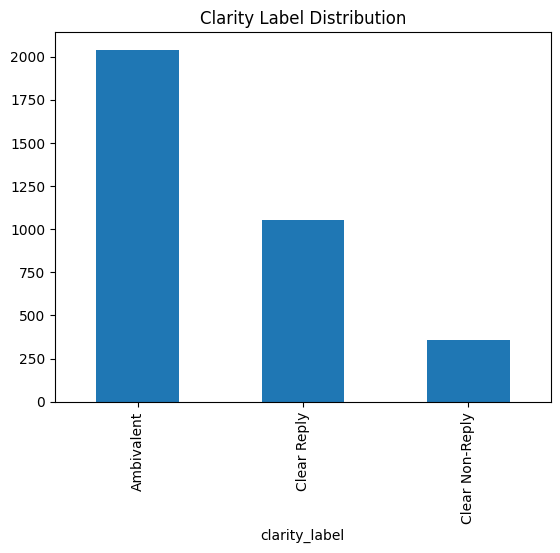


=== EVASION LABEL DISTRIBUTION ===
evasion_label
Explicit               30.510441
Dodging                20.475638
Implicit               14.153132
General                11.194896
Deflection             11.049884
Declining to answer     4.205336
Claims ignorance        3.451276
Clarification           2.668213
Partial/half-answer     2.291183
Name: proportion, dtype: float64


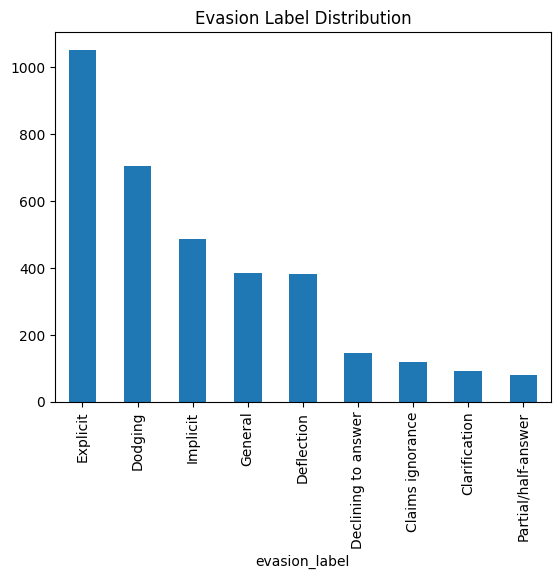

In [15]:
if 'clarity_label' in df.columns:
    print("\n=== CLARITY LABEL DISTRIBUTION ===")
    print(df['clarity_label'].value_counts(normalize=True) * 100)
    df['clarity_label'].value_counts().plot(kind='bar', title="Clarity Label Distribution")
    plt.show()

if 'evasion_label' in df.columns:
    print("\n=== EVASION LABEL DISTRIBUTION ===")
    print(df['evasion_label'].value_counts(normalize=True) * 100)
    df['evasion_label'].value_counts().plot(kind='bar', title="Evasion Label Distribution")
    plt.show()


             q_len        a_len       qa_len
count  3448.000000  3448.000000  3448.000000
mean     14.462007   293.572216   308.034223
std       8.833190   301.541101   303.761579
min       1.000000     1.000000     2.000000
25%       8.000000    56.000000    68.000000
50%      12.000000   207.000000   222.000000
75%      19.000000   440.000000   457.000000
max      80.000000  2117.000000  2140.000000


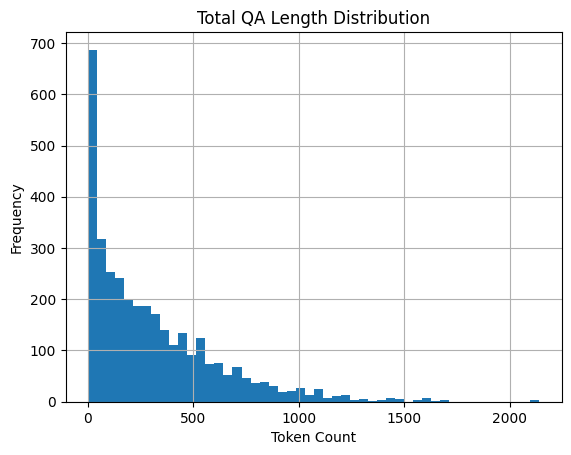

In [17]:
def word_count(text):
    return len(str(text).split())

df['q_len'] = df['question'].apply(word_count)
df['a_len'] = df['interview_answer'].apply(word_count)
df['qa_len'] = df['q_len'] + df['a_len']

print(df[['q_len', 'a_len', 'qa_len']].describe())

# Plot histograms
df['qa_len'].hist(bins=50)
plt.title("Total QA Length Distribution")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()


       overlap_count      jaccard
count    3448.000000  3448.000000
mean        1.812065     0.024375
std         2.004218     0.047151
min         0.000000     0.000000
25%         0.000000     0.000000
50%         1.000000     0.013072
75%         3.000000     0.030303
max        15.000000     1.000000


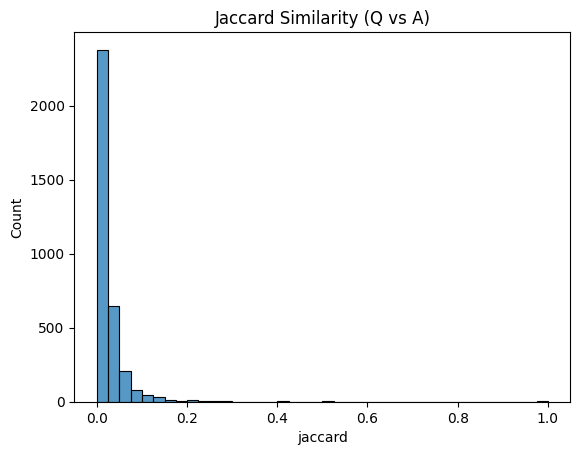

In [18]:
stop = set(stopwords.words("english"))

def preprocess(text):
    tokens = re.findall(r"\w+", str(text).lower())
    return [t for t in tokens if t not in stop]

def jaccard(a, b):
    a, b = set(a), set(b)
    if len(a | b) == 0:
        return 0
    return len(a & b) / len(a | b)

df['q_tokens'] = df['question'].apply(preprocess)
df['a_tokens'] = df['interview_answer'].apply(preprocess)

df['overlap_count'] = df.apply(lambda x: len(set(x.q_tokens) & set(x.a_tokens)), axis=1)
df['jaccard'] = df.apply(lambda x: jaccard(x.q_tokens, x.a_tokens), axis=1)

print(df[['overlap_count', 'jaccard']].describe())

sns.histplot(df['jaccard'], bins=40)
plt.title("Jaccard Similarity (Q vs A)")
plt.show()


In [19]:
evasion_phrases = {
    "decline": ["i cannot", "i won’t comment", "not going to comment", "i don't know"],
    "deflect": ["the real issue", "what i want to talk about", "let me say this"],
    "clarify": ["what do you mean", "let me clarify", "if I understand you"]
}

def count_phrases(text):
    text = text.lower()
    return {
        k: sum(1 for p in phrases if p in text)
        for k, phrases in evasion_phrases.items()
    }

counts = df['interview_answer'].apply(count_phrases)
counts_df = pd.DataFrame(counts.tolist())
df = pd.concat([df, counts_df], axis=1)

print("\n=== Evasion Cue Counts ===")
print(df[['decline','deflect','clarify']].sum())



=== Evasion Cue Counts ===
decline    298
deflect      0
clarify      2
dtype: int64


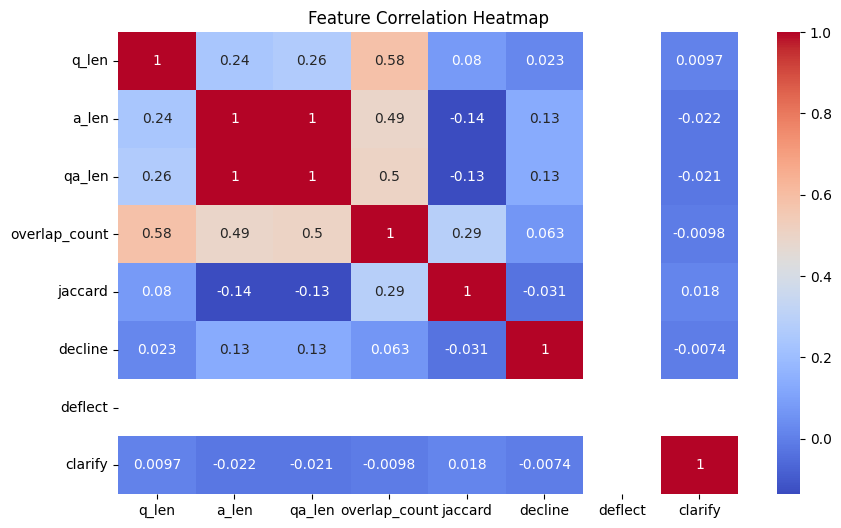

In [20]:
corr_cols = ['q_len', 'a_len', 'qa_len', 'overlap_count', 'jaccard', 
             'decline', 'deflect', 'clarify']

corr = df[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [21]:
if 'clarity_label' in df.columns:
    df.groupby('clarity_label')[['q_len','a_len','overlap_count','jaccard']].mean()


In [30]:
if 'clarity_label' in df.columns:
    for c in df['clarity_label'].unique():
        print("\n=== EXAMPLES FOR:", c, "===")
        # display(df[df['clarity_label'] == c].head(2)[['question','interview_answer']])
        print(df[df['clarity_label'] == c].head(2)[['question','interview_answer']])



=== EXAMPLES FOR: Clear Reply ===
                                            question  \
0  How would you respond to the accusation that t...   
4   Is the President's engagement with Asian coun...   

                                    interview_answer  
0  Well, look, first of all, theI am sincere abou...  
4  Well, I hope I get to see Mr. Xi sooner than l...  

=== EXAMPLES FOR: Ambivalent ===
                                            question  \
1  Do you think President Xi is being sincere abo...   
2   Do you believe the country's slowdown and gro...   

                                    interview_answer  
1  Well, look, first of all, theI am sincere abou...  
2  Look, I think China has a difficult economic p...  

=== EXAMPLES FOR: Clear Non-Reply ===
                                             question  \
10                  What did you talk about with him?   
25   Does the firing of the general and the rebell...   

                                     interview_answe